In [19]:
#TODO: Implementar algortimo incrementando el tamaño de datos hasta un billon y veindo el tiempo que tarda en un for

from sklearn.linear_model import LinearRegression
import numpy as np

np.random.seed(12)

# Generate some random data
m = 100
X = 5 * np.random.rand(m, 1)
y = 10 + 3 * X + np.random.randn(m, 1)

# y = theta * X
# thetha = (X.T * X)^-1 * X.T * y

from sklearn.preprocessing import add_dummy_feature

x_b = add_dummy_feature(X)
# Por agregar una columna de 1s. Para que en el producto punto se multiplique por el intercepto (theta0) Para que sobreviva se usa un vector column d e unos.
theta_best = np.linalg.inv(x_b.T @ x_b) @ x_b.T @ y
theta_best

array([[9.61451104],
       [3.09026453]])

In [18]:
from sklearn.preprocessing import add_dummy_feature
import time

sizes = [100, 1000, 10000, 100000, 1000000, 10000000, 100000000]
for m in sizes:
    np.random.seed(12)
    X = 5 * np.random.rand(m, 1)
    y = 10 + 3 * X + np.random.randn(m, 1)
    x_b = add_dummy_feature(X)
    start = time.time()
    theta_best = np.linalg.inv(x_b.T @ x_b) @ x_b.T @ y
    end = time.time()
    print(f"For m={m}, time={end-start:.4f}s")




For m=100, time=0.0000s
For m=1000, time=0.0000s
For m=10000, time=0.0030s
For m=100000, time=0.0053s
For m=1000000, time=0.0119s
For m=10000000, time=0.0593s


KeyboardInterrupt: 

In [5]:
X_new_data = np.array([[0], [2], [4], [6], [8], [10]])
X_new_data_b = add_dummy_feature(X_new_data)
y_predict = X_new_data_b @ theta_best
y_predict

array([[ 9.9995477 ],
       [15.99984244],
       [22.00013717],
       [28.00043191],
       [34.00072665],
       [40.00102139]])

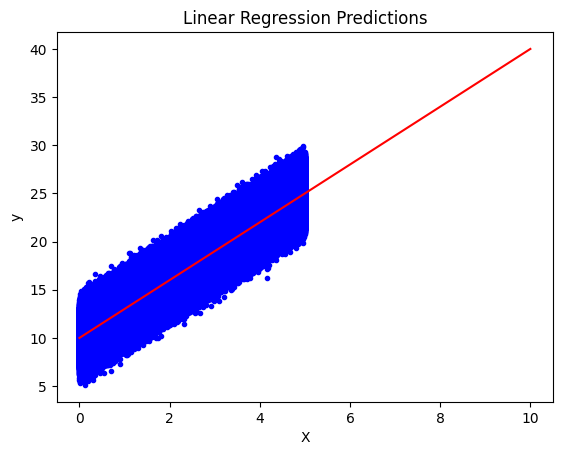

In [6]:
import matplotlib.pyplot as plt

plt.plot(X, y, "b.")
plt.plot(X_new_data, y_predict, "r-")
plt.xlabel("X") 
plt.ylabel("y")
plt.title("Linear Regression Predictions")
plt.show()

In [7]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([9.9995477]), array([[3.00014737]]))

In [8]:
# Scikit-learn también tiene una función para regresino lineal: SVD o descomposicion de valores regulares

np.linalg.pinv(x_b) @ y #pseudo inversa. El probelam de la ecuacion normal es que le resultado de todas las versiones no siempre es invertible.

array([[9.9995477 ],
       [3.00014737]])

In [9]:
import time

sizes = [100, 1000, 10000, 100000, 1000000, 10000000]
for m in sizes:
    np.random.seed(12)
    X = 5 * np.random.rand(m, 1)
    y = 10 + 3 * X + np.random.randn(m, 1)
    x_b = add_dummy_feature(X)
    start = time.time()
    np.linalg.pinv(x_b) @ y
    end = time.time()
    print(f"For m={m}, time={end-start:.4f}s")

# SKLEARN si o si usa la pseudo inversa.



For m=100, time=0.0000s
For m=1000, time=0.0000s
For m=10000, time=0.0000s
For m=100000, time=0.0036s
For m=1000000, time=0.0428s
For m=10000000, time=0.3565s


In [11]:
lr = 0.1
n_epochs = 1000

m = len(x_b)
np.random.seed(12)
theta = np.random.randn(2, 1)

for epoch in range(n_epochs):
    gradients = 2/m * x_b.T @ (x_b @ theta - y)
    theta = theta - lr * gradients

theta

KeyboardInterrupt: 

In [ ]:
for epoca in range(n_epochs):
    gradient_vector = 2/m * x_b.T @ (x_b @ theta - y)
    theta_gd = theta - lr * gradient_vector

In [12]:
# EL problema del descenso de gradiente por lote batch gradient descent es que en cada etapa se se usa todo el training dataset.
# EN problemas de alta dimensionalidad.

# Que pasa si no entrenamos con todo el dataset? Stochastic Gradient Descent (SGD) o descenso de gradiente estocástico. En cada etapa se usa un solo ejemplo de entrenamiento. Esto hace que el proceso de entrenamiento sea mucho más rápido, pero también hace que el proceso de convergencia sea mucho más ruidoso.
# Otro problema es como sabemos cuando ya llega al min y por eso al ratio de learnign rate debe irse bajando y reduciendo para que el algoritmo converja.

# Son dos ideas una usa sola una instancia, pero puede ser ruidoso y puede que salte y para eso el learning rate tiene que decaer.

# Stochastic Gradient Descent (SGD)

n_epochs_sgq = 50

theta_sgd = np.random.randn(2, 1) # random initialization

# Hiperparametros para decaiga el Lr: Decay LR
t0, t1 = 5, 50

def learning_schedule(t):
    return t0 / (t + t1) # Aqui hay varuas funciones, este es un clasico, scikit usa otra

# lr = 0.1

for epoch in range(n_epochs_sgq):
    for iteracion in range(m):
        random_index = np.random.randint(m)
        xi = x_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradient_vector_sgd = 2 * xi.T @ (xi @ theta_sgd - yi) # No va el m
        lr = learning_schedule(epoch * m + iteracion) # El learning rate se va reduciendo a medida que avanza el entrenamiento
        theta_sgd = theta_sgd - lr * gradient_vector_sgd
    print(learning_schedule(epoch))
theta_sgd


0.1


KeyboardInterrupt: 

In [13]:
import numpy as np

n_epochs_sgd = 50
theta_sgd = np.random.randn(2, 1)  # inicialización aleatoria

# Hiperparámetros para decay del learning rate
t0, t1 = 5, 50

def learning_schedule(t):
    return t0 / (t + t1)

m = x_b.shape[0]

for epoch in range(n_epochs_sgd):
    for iteracion in range(m):
        random_index = np.random.randint(m)
        xi = x_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]

        gradient_vector_sgd = 2 * xi.T @ (xi @ theta_sgd - yi)
        lr = learning_schedule(epoch * m + iteracion)
        theta_sgd = theta_sgd - lr * gradient_vector_sgd

    print(f"Epoch {epoch+1}, lr final = {lr}")

print(theta_sgd)

Epoch 1, lr final = 4.99997550012005e-07


KeyboardInterrupt: 

In [ ]:
# Mini batch sgd

import numpy as np

n_epochs_mbgd = 50
batch_size = 20

theta_mbgd = np.random.randn(2, 1)  # inicialización aleatoria

# Hiperparámetros para decay del learning rate
t0, t1 = 200, 1000

def learning_schedule(t):
    return t0 / (t + t1)

m = x_b.shape[0]
t = 0

for epoch in range(n_epochs_mbgd):
    shuffled_indices = np.random.permutation(m)
    x_b_shuffled = x_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]

    for i in range(0, m, batch_size):
        xi = x_b_shuffled[i:i + batch_size]
        yi = y_shuffled[i:i + batch_size]

        gradient_vector_mbgd = (2 / len(xi)) * xi.T @ (xi @ theta_mbgd - yi)
        lr = learning_schedule(t)

        theta_mbgd = theta_mbgd - lr * gradient_vector_mbgd
        t += 1

    print(f"Epoch {epoch + 1}, lr = {lr}")

print(theta_mbgd)